In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/study-deep-learning'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/study-deep-learning.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/study-deep-learning
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/study-deep-learning/8
    print("準備完了！このまま下のセルを実行できます。")

# 第8章 誤差逆伝播法 (Backpropagation)
## 8.1 勾配の評価 (Evaluation of Gradients)

### 本節の概要と位置づけ
前章（第7章）では、ニューラルネットワークのパラメータを学習するための様々な勾配降下法（最急降下法、モーメンタム法、Adam、正規化手法など）を学びました。これらの最適化アルゴリズムはすべて、誤差関数のパラメータに関する勾配ベクトル $\nabla E(\mathbf{w})$ を利用できることを前提としています。

本章（第8章）では、この**勾配ベクトルおよび高階導関数（ヤコビ行列やヘッセ行列）を数値的・解析的・自動的に評価するアルゴリズム**を体系的に探求します。

「誤差逆伝播法（Backpropagation; 誤差逆伝播アルゴリズム）」という用語は、機械学習の文献において様々な意味（ネットワーク構造そのものを指したり、勾配降下を含む訓練プロセス全体を指したり）で用いられてきましたが、本書では**「誤差関数のネットワーク重みやバイアスに関する導関数（勾配）を数値的に評価するための計算手順」**として厳密に定義・使用します。

---

### 本節 (8.1節) の構成
1. **8.1.1 単層ネットワーク (Single-layer networks)**:
   - 線形モデル $y_k = \sum_i w_{ki} x_i$ と二乗和誤差 $E_n = \frac{1}{2} \sum_k (y_{nk} - t_{nk})^2$ に対する勾配 $\frac{\partial E_n}{\partial w_{ji}} = (y_{nj} - t_{nj}) x_{ni}$ (Eq 8.4) の局所計算的解釈。
2. **8.1.2 一般の順伝播ネットワーク (General feed-forward networks)**:
   - 任意の有向非循環グラフ (DAG) トポロジーにおける順伝播方程式 $a_j = \sum_i w_{ji} z_i$ (Eq 8.5) と活性化 $z_j = h(a_j)$ (Eq 8.6)。
   - 誤差信号の定義 $\delta_j \equiv \frac{\partial E_n}{\partial a_j}$ (Eq 8.8) と重み勾配 $\frac{\partial E_n}{\partial w_{ji}} = \delta_j z_i$ (Eq 8.10)。
   - 出力ユニットの正準連結誤差 $\delta_k = y_k - t_k$ (Eq 8.11)。
   - 隠れユニットにおける誤差逆伝播の漸化式 $\delta_j = h'(a_j) \sum_k w_{kj} \delta_k$ (Eq 8.13)。
   - **Algorithm 8.1**: 誤差逆伝播法の完全なアルゴリズム仕様。
   - **Figure 8.1**: 順伝播と逆伝播における情報流の幾何学的対比。
3. **8.1.3 具象例：2層多層パーセプトロン (A simple example)**:
   - 入力 $D$ 次元、$\tanh$ 活性化隠れユニット $M$ 個 ($h'(a) = 1 - z^2$)、線形出力ユニット $K$ 個の2層MLPの完全な順伝播・逆伝播導出。
4. **8.1.4 数値微分 (Numerical differentiation)**:
   - 前進差分 $O(\epsilon)$ (Eq 8.24) と中心差分 $O(\epsilon^2)$ (Eq 8.25) のテイラー展開による誤差解析。
   - 逆伝播法 $O(W)$ に対する数値微分の計算量 $O(W^2)$。
   - 浮動小数点丸め誤差と打ち切り誤差のトレードオフ、最適ステップ幅 $\epsilon$ の挙動。
   - **Figure 8.2**: ステップ幅 $\epsilon$ に対する数値微分誤差の両対数プロット（傾き1と傾き2の検証）。
5. **8.1.5 ヤコビ行列 (The Jacobian matrix)**:
   - 定義 $J_{ki} = \frac{\partial y_k}{\partial x_i}$ (Eq 8.26) とモジュール化深層学習における誤差逆伝播 (Eq 8.27)。
   - 入力摂動に対する感度解析 $\Delta y_k \approx \sum_i J_{ki} \Delta x_i$ (Eq 8.28)。
   - ヤコビ行列の逆伝播漸化式 (Eq 8.29-8.34) と線形・シグモイド・ソフトマックス出力での境界条件。
   - **Figure 8.3**: モジュール化アーキテクチャとヤコビ行列による誤差逆伝播。
6. **8.1.6 ヘッセ行列 (The Hessian matrix)**:
   - 2階微分 $H_{ij} = \frac{\partial^2 E}{\partial w_i \partial w_j}$ (Eq 8.37) の定義と応用（2次最適化、ベイズ推論、重み量子化）。
   - 計算量：厳密評価 $O(W^2)$、逆行列 $O(W^3)$、ヘッセ・ベクトル積 $v^T H$ の $O(W)$ 高速計算法 (Pearlmutter 1994)。
   - 対角近似 (Diagonal approximation) とその限界。
   - 外積近似（ガウス・ニュートン近似 / レーベンバーグ・マルカート近似） $H \approx \sum_n \nabla a_n \nabla a_n^T$ (Eq 8.40) の厳密な導出と条件付き期待値による2階項無視の正当化。

In [1]:
# 環境セットアップと共通モジュールのインポート
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

# プロジェクトルートのパス解決
current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, "..")) if os.path.basename(current_dir) == "8" else current_dir
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from common.evaluation_of_gradients import (
    SingleLayerNetwork,
    TwoLayerMLP,
    FeedForwardNeuralNetwork,
    finite_difference_gradient,
    central_difference_gradient,
    check_gradient,
    compute_jacobian_analytical,
    compute_jacobian_numerical,
    compute_hessian_outer_product,
    compute_exact_hessian_numerical,
    hessian_vector_product_fd,
    generate_figure_8_1,
    generate_figure_8_2,
    generate_figure_8_3,
    generate_all_section_8_1_figures,
    sigmoid,
    sigmoid_deriv,
    tanh,
    tanh_deriv,
    softmax,
)

print("Chapter 8 Section 8.1 modules loaded successfully.")


Chapter 8 Section 8.1 modules loaded successfully.


## 8.1.1 単層ネットワーク (Single-layer networks)

### 数理モデルと誤差関数
まず、入力変数 $x_i$ の線形結合として出力 $y_k$ が与えられる最もシンプルな単層モデルを考えます：
$$
y_k = \sum_{i} w_{ki} x_i \tag{8.2}
$$
バイアスパラメータ $w_{k0}$ は、常に $x_0 = 1$ をとるダミー入力を導入することで重みベクトル内に統一的に内包できます。

特定の訓練データ点 $n$ に対する二乗和誤差（Sum-of-squares error）関数は次式で定義されます：
$$
E_n = \frac{1}{2} \sum_{k} (y_{nk} - t_{nk})^2 \tag{8.3}
$$
ここで $y_{nk} = y_k(\mathbf{x}_n; \mathbf{w})$ であり、$t_{nk}$ は対応する目標値です。

### 局所計算としての重み勾配
重み $w_{ji}$ に関する誤差関数の偏微分を計算すると：
$$
\frac{\partial E_n}{\partial w_{ji}} = (y_{nj} - t_{nj}) x_{ni} \tag{8.4}
$$
この式は、**結合リンク $w_{ji}$ の出力端における「誤差信号」 $(y_{nj} - t_{nj})$ と、入力端における「変数」 $x_{ni}$ の積**として解釈できます。

第5章（5.4.3項）で確認したように、ロジスティック・シグモイド活性化関数とクロスエントロピー誤差、あるいはソフトマックス活性化関数と多クラスクロスエントロピー誤差（正準連結関数）の組み合わせにおいても、全く同一の形式 $\frac{\partial E_n}{\partial w_{ji}} = (y_{nj} - t_{nj}) x_{ni}$ が導かれます。

この局所的な計算構造が、多層ニューラルネットワークへとどのように一般化されるかを次項で導出します。

In [2]:
# 単層ネットワークの実装と勾配の局所計算の確認
np.random.seed(42)
N, D, K = 5, 3, 2
X = np.random.randn(N, D)
T = np.random.randn(N, K)

single_net = SingleLayerNetwork(in_features=D, out_features=K, seed=42)
loss = single_net.compute_loss(X, T)
grad_W, grad_b = single_net.backward(X, T)

print(f"訓練データ数 N={N}, 入力次元 D={D}, 出力次元 K={K}")
print(f"二乗和誤差 E = {loss:.6f}")
print("解析的重み勾配 del E / del W:\n", np.round(grad_W, 4))
print("解析的バイアス勾配 del E / del b:\n", np.round(grad_b, 4))

# 数値微分（中心差分）による検証
eps = 1e-6
num_grad_W = np.zeros_like(grad_W)
for k in range(K):
    for i in range(D):
        w_orig = single_net.W[k, i]
        single_net.W[k, i] = w_orig + eps
        l_plus = single_net.compute_loss(X, T)
        single_net.W[k, i] = w_orig - eps
        l_minus = single_net.compute_loss(X, T)
        single_net.W[k, i] = w_orig
        num_grad_W[k, i] = (l_plus - l_minus) / (2.0 * eps)

diff_norm = np.linalg.norm(grad_W - num_grad_W)
print(f"解析的勾配と数値微分の絶対差ノルム: {diff_norm:.2e}")
assert diff_norm < 1e-6


訓練データ数 N=5, 入力次元 D=3, 出力次元 K=2
二乗和誤差 E = 15.432636
解析的重み勾配 del E / del W:
 [[ 2.7805 -3.1109 -3.2323]
 [ 3.6121 -9.907  -6.9994]]
解析的バイアス勾配 del E / del b:
 [4.2985 7.2337]
解析的勾配と数値微分の絶対差ノルム: 2.14e-09


## 8.1.2 一般の順伝播ネットワーク (General feed-forward networks)

### 順伝播方程式 (Forward Propagation)
任意の有向非循環グラフ (DAG) 構造を持つ一般的な順伝播ネットワークにおいて、各ユニット $j$ はその入力信号の重み付き和を計算します：
$$
a_j = \sum_{i} w_{ji} z_i \tag{8.5}
$$
ここで $a_j$ は**事前活性化（Pre-activation）**、バイアスは固定入力 $z_0 = 1$ として統一され、$z_i$ は直前または下位のユニットの出力（または入力ベクトル $x_i$）です。
この $a_j$ は非線形活性化関数 $h(\cdot)$ によって変換され、ユニット $j$ の**活性化（Activation）** $z_j$ を与えます：
$$
z_j = h(a_j) \tag{8.6}
$$

### 連鎖律と誤差信号 $\delta_j$ の導入
訓練データ点 $n$ に対する誤差 $E_n$ の重み $w_{ji}$ に関する偏微分を評価します。$E_n$ は事前活性化 $a_j$ を通じてのみ重み $w_{ji}$ に依存するため、微分積分学の**連鎖律（Chain rule）**を適用できます：
$$
\frac{\partial E_n}{\partial w_{ji}} = \frac{\partial E_n}{\partial a_j} \frac{\partial a_j}{\partial w_{ji}} \tag{8.7}
$$
ここで、ユニット $j$ における**局所誤差信号（Error）** $\delta_j$ を次のように定義します：
$$
\delta_j \equiv \frac{\partial E_n}{\partial a_j} \tag{8.8}
$$
式 (8.5) より $\frac{\partial a_j}{\partial w_{ji}} = z_i$ (Eq 8.9) であるため、重みに関する勾配は極めて端正な形式に帰着します：
$$
\frac{\partial E_n}{\partial w_{ji}} = \delta_j z_i \tag{8.10}
$$
すなわち、重み $w_{ji}$ の微分は、**リンクの出力側ユニットの誤差 $\delta_j$ と入力側ユニットの活性化 $z_i$ の単純な積**で得られます。

### 誤差逆伝播の漸化式
1. **出力ユニット $k$ の誤差**:
   二乗和誤差と線形出力、または正準連結関数を用いる場合：
   $$
   \delta_k = y_k - t_k \tag{8.11}
   $$
2. **隠れユニット $j$ の誤差**:
   ユニット $j$ の事前活性化 $a_j$ の微小変化は、ユニット $j$ が接続を送っているすべての後続ユニット $k$ の事前活性化 $a_k$ を通じて誤差 $E_n$ に影響を与えます。したがって連鎖律より：
   $$
   \delta_j \equiv \frac{\partial E_n}{\partial a_j} = \sum_{k} \frac{\partial E_n}{\partial a_k} \frac{\partial a_k}{\partial a_j} = \sum_{k} \delta_k \frac{\partial a_k}{\partial a_j} \tag{8.12}
   $$
   ここで $a_k = \sum_l w_{kl} z_l$ かつ $z_j = h(a_j)$ であるため、$\frac{\partial a_k}{\partial a_j} = w_{kj} h'(a_j)$ となります。これを代入すると、著名な**誤差逆伝播の漸化式（Backpropagation formula）**が得られます：
   $$
   \delta_j = h'(a_j) \sum_{k} w_{kj} \delta_k \tag{8.13}
   $$

---

### Algorithm 8.1: 誤差逆伝播法 (Backpropagation)
- **入力**: 入力ベクトル $\mathbf{x}_n$、パラメータ $\mathbf{w}$、誤差関数 $E_n$、活性化関数 $h(a)$
- **出力**: 誤差関数の全重みに関する導関数 $\{\frac{\partial E_n}{\partial w_{ji}}\}$
1. **順伝播 (Forward Propagation)**:
   - 全ての隠れ・出力ユニット $j$ について、トポロジカル順序に従い $a_j \leftarrow \sum_i w_{ji} z_i$ および $z_j \leftarrow h(a_j)$ を計算。
2. **出力誤差の計算**:
   - 出力ユニット $k$ について、$\delta_k \leftarrow \frac{\partial E_n}{\partial a_k}$ を計算。
3. **逆伝播 (Backward Propagation)**:
   - 出力層から入力層へ向かう逆順序で、各隠れユニット $j$ について：
     $$
     \delta_j \leftarrow h'(a_j) \sum_{k} w_{kj} \delta_k
     $$
     $$
     \frac{\partial E_n}{\partial w_{ji}} \leftarrow \delta_j z_i
     $$
4. ミニバッチまたはデータセット全体の総勾配は、各データ点 $n$ の導関数の総和として集約：
   $$
   \frac{\partial E}{\partial w_{ji}} = \sum_{n=1}^N \frac{\partial E_n}{\partial w_{ji}} \tag{8.14}
   $$

Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/8/result/fig_8_1_backprop_flow.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_8_1_backprop_flow.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/8/result/Figure_8_1.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_8_1.png


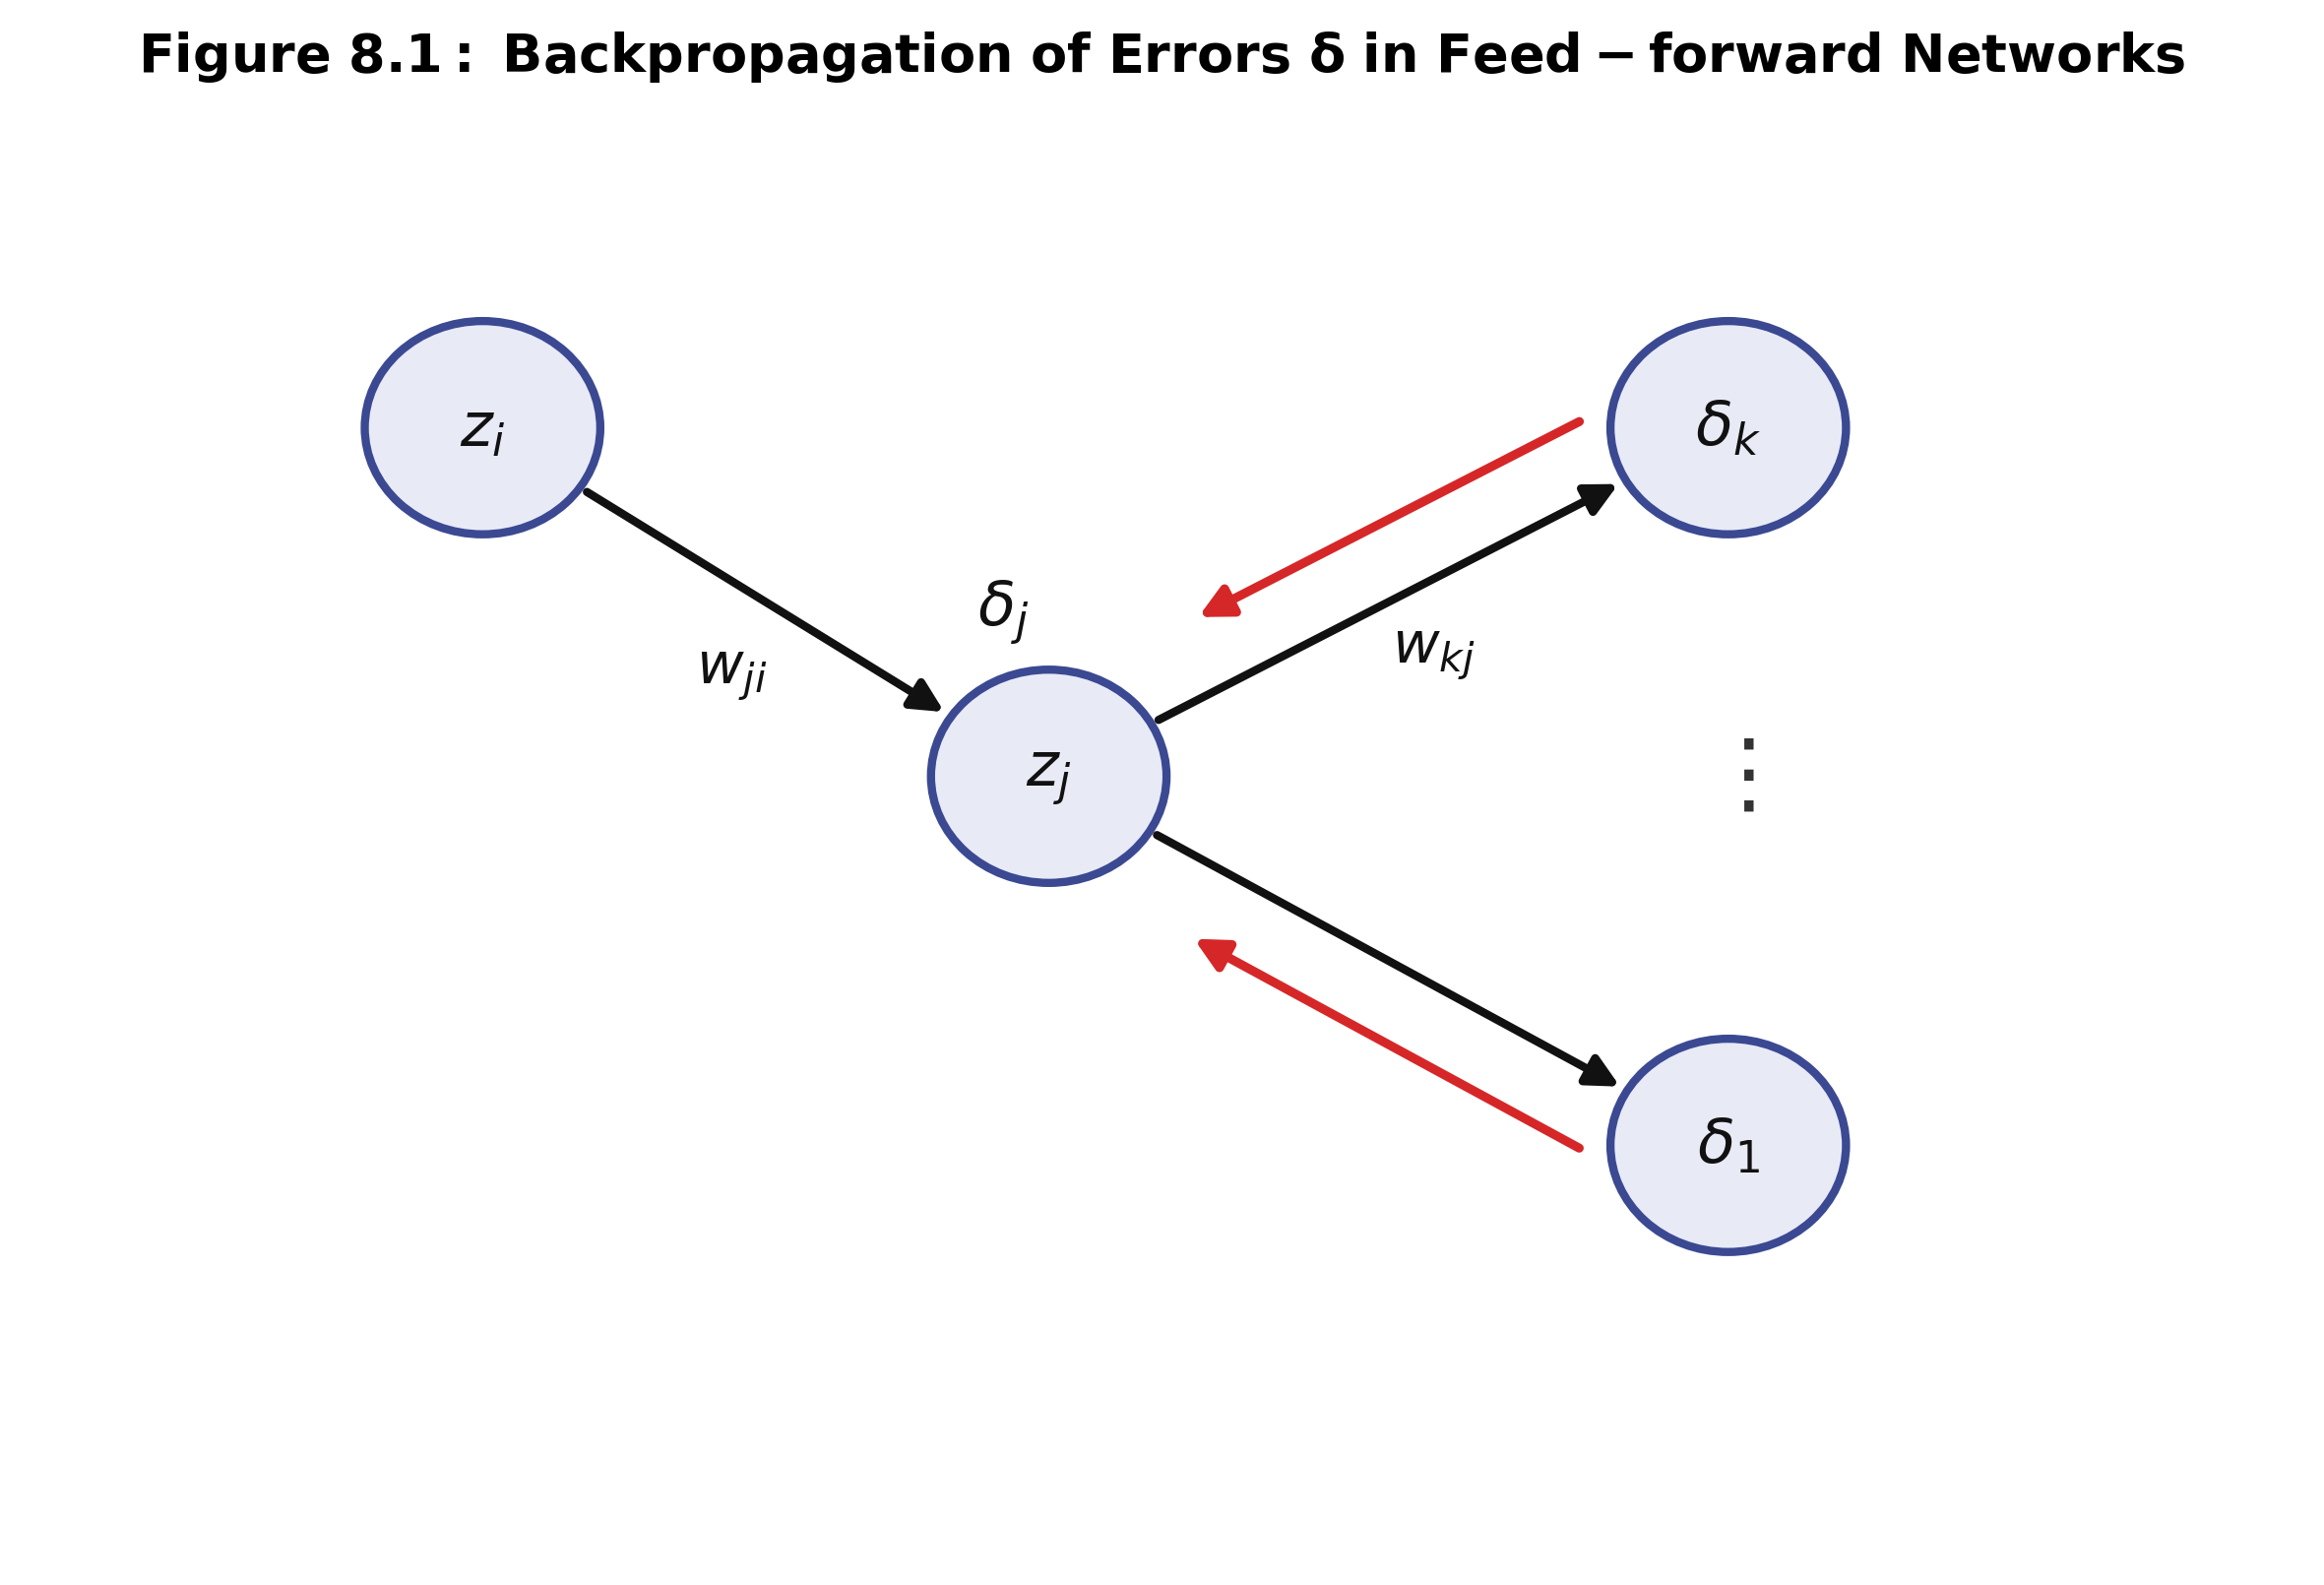

In [3]:
# Figure 8.1の生成と表示（誤差逆伝播の概念図）
fig_8_1 = generate_figure_8_1(save_both=True)
plt.show()


## 8.1.3 具象例：2層多層パーセプトロン (A simple example)

### ネットワーク構造と数理導出
一般論を具象化するため、図 6.9 の標準的な2層ネットワークを考えます：
- 入力ベクトル: $\mathbf{x} \in \mathbb{R}^D$ (バイアス項 $x_0 = 1$)
- 隠れ層: $M$ 個のユニット、活性化関数 $h(a) = \tanh(a)$ (Eq 8.15)
  - 微分特性: $h'(a) = 1 - \tanh^2(a) = 1 - z^2$ (Eq 8.16)
- 出力層: $K$ 個の線形ユニット $y_k = a_k$
- 誤差関数: 二乗和誤差 $E_n = \frac{1}{2} \sum_{k=1}^K (y_k - t_k)^2$ (Eq 8.17)

### 順伝播・逆伝播の計算手順
1. **順伝播**:
   $$
   a_j = \sum_{i=0}^D w_{ji}^{(1)} x_i \tag{8.18}
   $$
   $$
   z_j = \tanh(a_j) \tag{8.19}
   $$
   $$
   y_k = \sum_{j=0}^M w_{kj}^{(2)} z_j \tag{8.20}
   $$
2. **出力層の誤差信号**:
   $$
   \delta_k = y_k - t_k \tag{8.21}
   $$
3. **隠れ層への誤差逆伝播**:
   $$
   \delta_j = (1 - z_j^2) \sum_{k=1}^K w_{kj}^{(2)} \delta_k \tag{8.22}
   $$
4. **第1層および第2層の重み勾配**:
   $$
   \frac{\partial E_n}{\partial w_{ji}^{(1)}} = \delta_j x_i, \quad \frac{\partial E_n}{\partial w_{kj}^{(2)}} = \delta_k z_j \tag{8.23}
   $$

In [4]:
# 2層MLPの数値シミュレーションと逆伝播勾配の検証
D, M, K = 3, 4, 2
mlp = TwoLayerMLP(D=D, M=M, K=K, seed=42)

# テストデータ
X_sample = np.array([[0.5, -0.2, 0.8], [0.1, 0.9, -0.4]])
T_sample = np.array([[1.0, 0.0], [0.0, 1.0]])

# 順伝播
_, _, _, Y_pred = mlp.forward(X_sample)
error_val = mlp.compute_error(X_sample, T_sample)
print(f"2層MLP出力 Y:\n", np.round(Y_pred, 4))
print(f"二乗和誤差 E: {error_val:.6f}")

# 逆伝播による勾配計算
g_W1, g_b1, g_W2, g_b2 = mlp.backward(X_sample, T_sample)
ana_grad = mlp.get_gradient_vector(X_sample, T_sample)

# 数値微分（中心差分）との比較
num_grad = central_difference_gradient(
    lambda p: (mlp.set_parameter_vector(p), mlp.compute_error(X_sample, T_sample))[1],
    mlp.get_parameter_vector(),
    eps=1e-6,
)

rel_err = np.linalg.norm(ana_grad - num_grad) / (np.linalg.norm(ana_grad) + np.linalg.norm(num_grad))
print(f"全パラメータ数 W = {mlp.num_parameters}")
print(f"逆伝播勾配と中心差分の相対誤差: {rel_err:.2e} (< 1e-6)")
assert rel_err < 1e-6


2層MLP出力 Y:
 [[-0.0337  0.1846]
 [-0.517   0.1029]]
二乗和誤差 E: 1.087336
全パラメータ数 W = 26
逆伝播勾配と中心差分の相対誤差: 6.39e-11 (< 1e-6)


## 8.1.4 数値微分 (Numerical differentiation)

### 計算量解析：$O(W)$ vs $O(W^2)$
誤差逆伝播法の最も重要な利点は、その**計算効率（Computational Efficiency）**にあります。
全重み・バイアスパラメータ数を $W$ とします。
- **誤差逆伝播法**: 1回の順伝播で $O(W)$、逆伝播で $O(W)$ の演算を要するため、勾配全体の評価コストは **$O(W)$** です。
- **数値微分（差分法）**: 各パラメータ $w_{ji}$ を個別に微小量 $\epsilon$ だけ変化させて順伝播をやり直す必要があります。$W$ 個の重みそれぞれに $O(W)$ の順伝播が必要となるため、総計算コストは **$O(W^2)$** に爆発します。

現代の深層学習モデルは数百万〜数千億のパラメータを持つため、$O(W^2)$ の数値微分による学習は物理的に不可能です。しかし、**中心差分法は逆伝播コードの正確性を数学的に検証（Gradient Checking）する極めて強力なデバッグツール**として不可欠です。

### 前進差分法 vs 中心差分法
1. **前進差分（1点差分）**:
   $$
   \frac{\partial E_n}{\partial w_{ji}} = \frac{E_n(w_{ji} + \epsilon) - E_n(w_{ji})}{\epsilon} + O(\epsilon) \tag{8.24}
   $$
   テイラー展開: $E(w+\epsilon) = E(w) + E'(w)\epsilon + \frac{1}{2}E''(w)\epsilon^2 + O(\epsilon^3)$ より、誤差の主要項は $\frac{1}{2}E''(w)\epsilon$ であり、$O(\epsilon)$ の1次精度です。
2. **対称中心差分（2点差分）**:
   $$
   \frac{\partial E_n}{\partial w_{ji}} = \frac{E_n(w_{ji} + \epsilon) - E_n(w_{ji} - \epsilon)}{2\epsilon} + O(\epsilon^2) \tag{8.25}
   $$
   $E(w+\epsilon)$ と $E(w-\epsilon)$ のテイラー展開を差し引くと、**奇数次項（1次項など）が完全に相殺**され、残余誤差は $\frac{1}{6}E'''(w)\epsilon^2 = O(\epsilon^2)$ の2次精度となります（Exercise 8.3）。

### 打ち切り誤差と浮動小数点丸め誤差の相剋
- $\epsilon$ が大きい領域では、数式近似に伴う**打ち切り誤差（Truncation error）**が支配的であり、前進差分は傾き1 ($O(\epsilon)$)、中心差分は傾き2 ($O(\epsilon^2)$) のベキ乗則に従って誤差が減少します。
- しかし、計算機上の有限精度浮動小数点（マシンイプシロン $\eta_M$）においては、$\epsilon$ が過小になると分子の桁落ち（Round-off error）による雑音 $\sim \frac{\eta_M}{\epsilon}$ が急増します。
- したがって、数値微分の誤差曲線はV字型（またはバスタブ曲線）を描き、最小誤差を与える最適な $\epsilon$ が存在します。

Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/8/result/fig_8_2_gradient_finite_differences.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_8_2_gradient_finite_differences.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/8/result/Figure_8_2.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_8_2.png


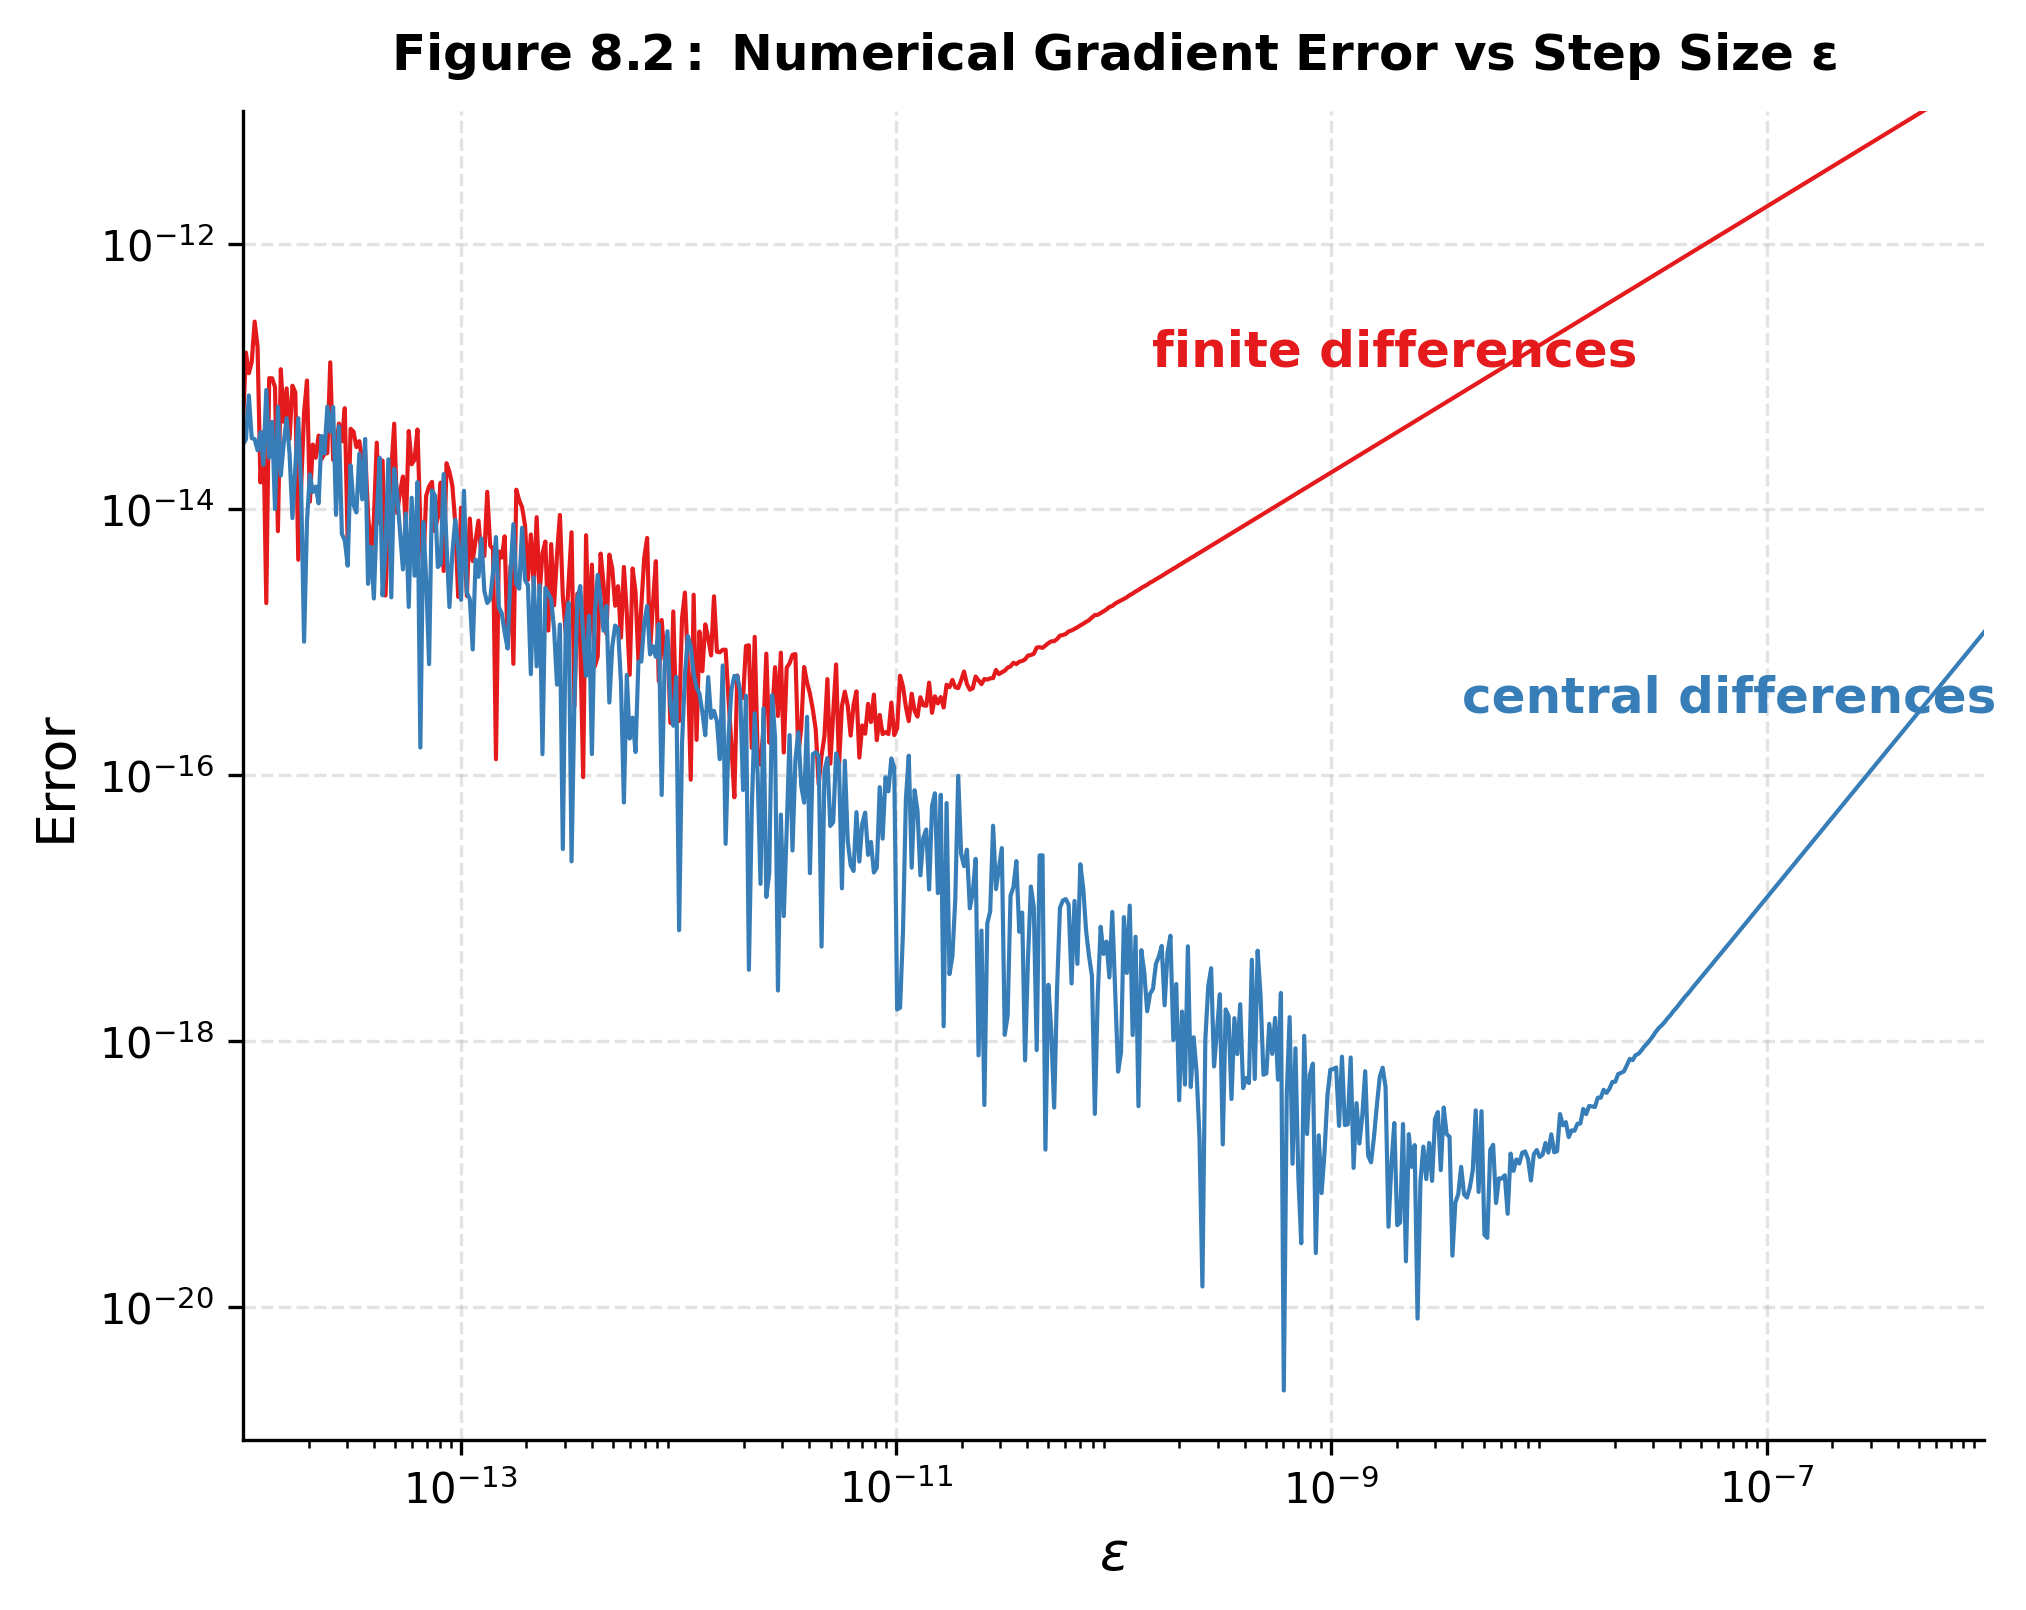

In [5]:
# Figure 8.2の生成と表示（ステップ幅 epsilon に対する数値微分誤差）
fig_8_2 = generate_figure_8_2(save_both=True)
plt.show()


## 8.1.5 ヤコビ行列 (The Jacobian matrix)

### 定義とモジュール化深層学習における役割
誤差逆伝播法の計算パラダイムは、重みに関する勾配評価にとどまらず、**ネットワーク出力の入力変数に関する偏導関数（ヤコビ行列）**の評価にもそのまま拡張できます：
$$
J_{ki} \equiv \frac{\partial y_k}{\partial x_i} \tag{8.26}
$$

ヤコビ行列は、下図（Figure 8.3）に示すように複数の独立したモジュールが結合された深層学習アーキテクチャにおいて極めて重要な役割を果たします。システム全体においてパラメータ $w$ に関する誤差 $E$ を最小化したい場合、連鎖律より：
$$
\frac{\partial E}{\partial w} = \sum_{k, j} \frac{\partial E}{\partial y_k} \frac{\partial y_k}{\partial z_j} \frac{\partial z_j}{\partial w} \tag{8.27}
$$
右辺中央の項 $\frac{\partial y_k}{\partial z_j}$ こそが、モジュール間の誤差逆伝播を媒介するヤコビ行列です。

### 局所感度解析
ヤコビ行列は、入力変数 $\mathbf{x}$ の微小変動 $\Delta x_i$ に対する出力 $\mathbf{y}$ の応答感度を表します：
$$
\Delta y_k \approx \sum_{i} \frac{\partial y_k}{\partial x_i} \Delta x_i = \sum_i J_{ki} \Delta x_i \tag{8.28}
$$

### ヤコビ行列の逆伝播漸化式
ヤコビ行列の要素 $J_{ki}$ は、事前活性化に関する微分 $\frac{\partial y_k}{\partial a_j}$ を後続層から逆伝播することで効率的に評価できます：
$$
J_{ki} = \frac{\partial y_k}{\partial x_i} = \sum_j w_{ji} \frac{\partial y_k}{\partial a_j} \tag{8.29}
$$
$$
\frac{\partial y_k}{\partial a_j} = h'(a_j) \sum_{l} w_{lj} \frac{\partial y_k}{\partial a_l} \tag{8.30}
$$

出力層における境界条件は、活性化関数に応じて定まります：
- **線形出力**: $\frac{\partial y_k}{\partial a_l} = \delta_{kl}$ (クロネッカーのデルタ, Eq 8.31)
- **ロジスティック・シグモイド出力**: $\frac{\partial y_k}{\partial a_l} = \delta_{kl} \sigma'(a_l) = \delta_{kl} y_k (1 - y_k)$ (Eq 8.33)
- **ソフトマックス出力**: $\frac{\partial y_k}{\partial a_l} = \delta_{kl} y_k - y_k y_l$ (Eq 8.34)

Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/8/result/fig_8_3_modular_architecture_jacobian.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_8_3_modular_architecture_jacobian.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/8/result/Figure_8_3.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_8_3.png


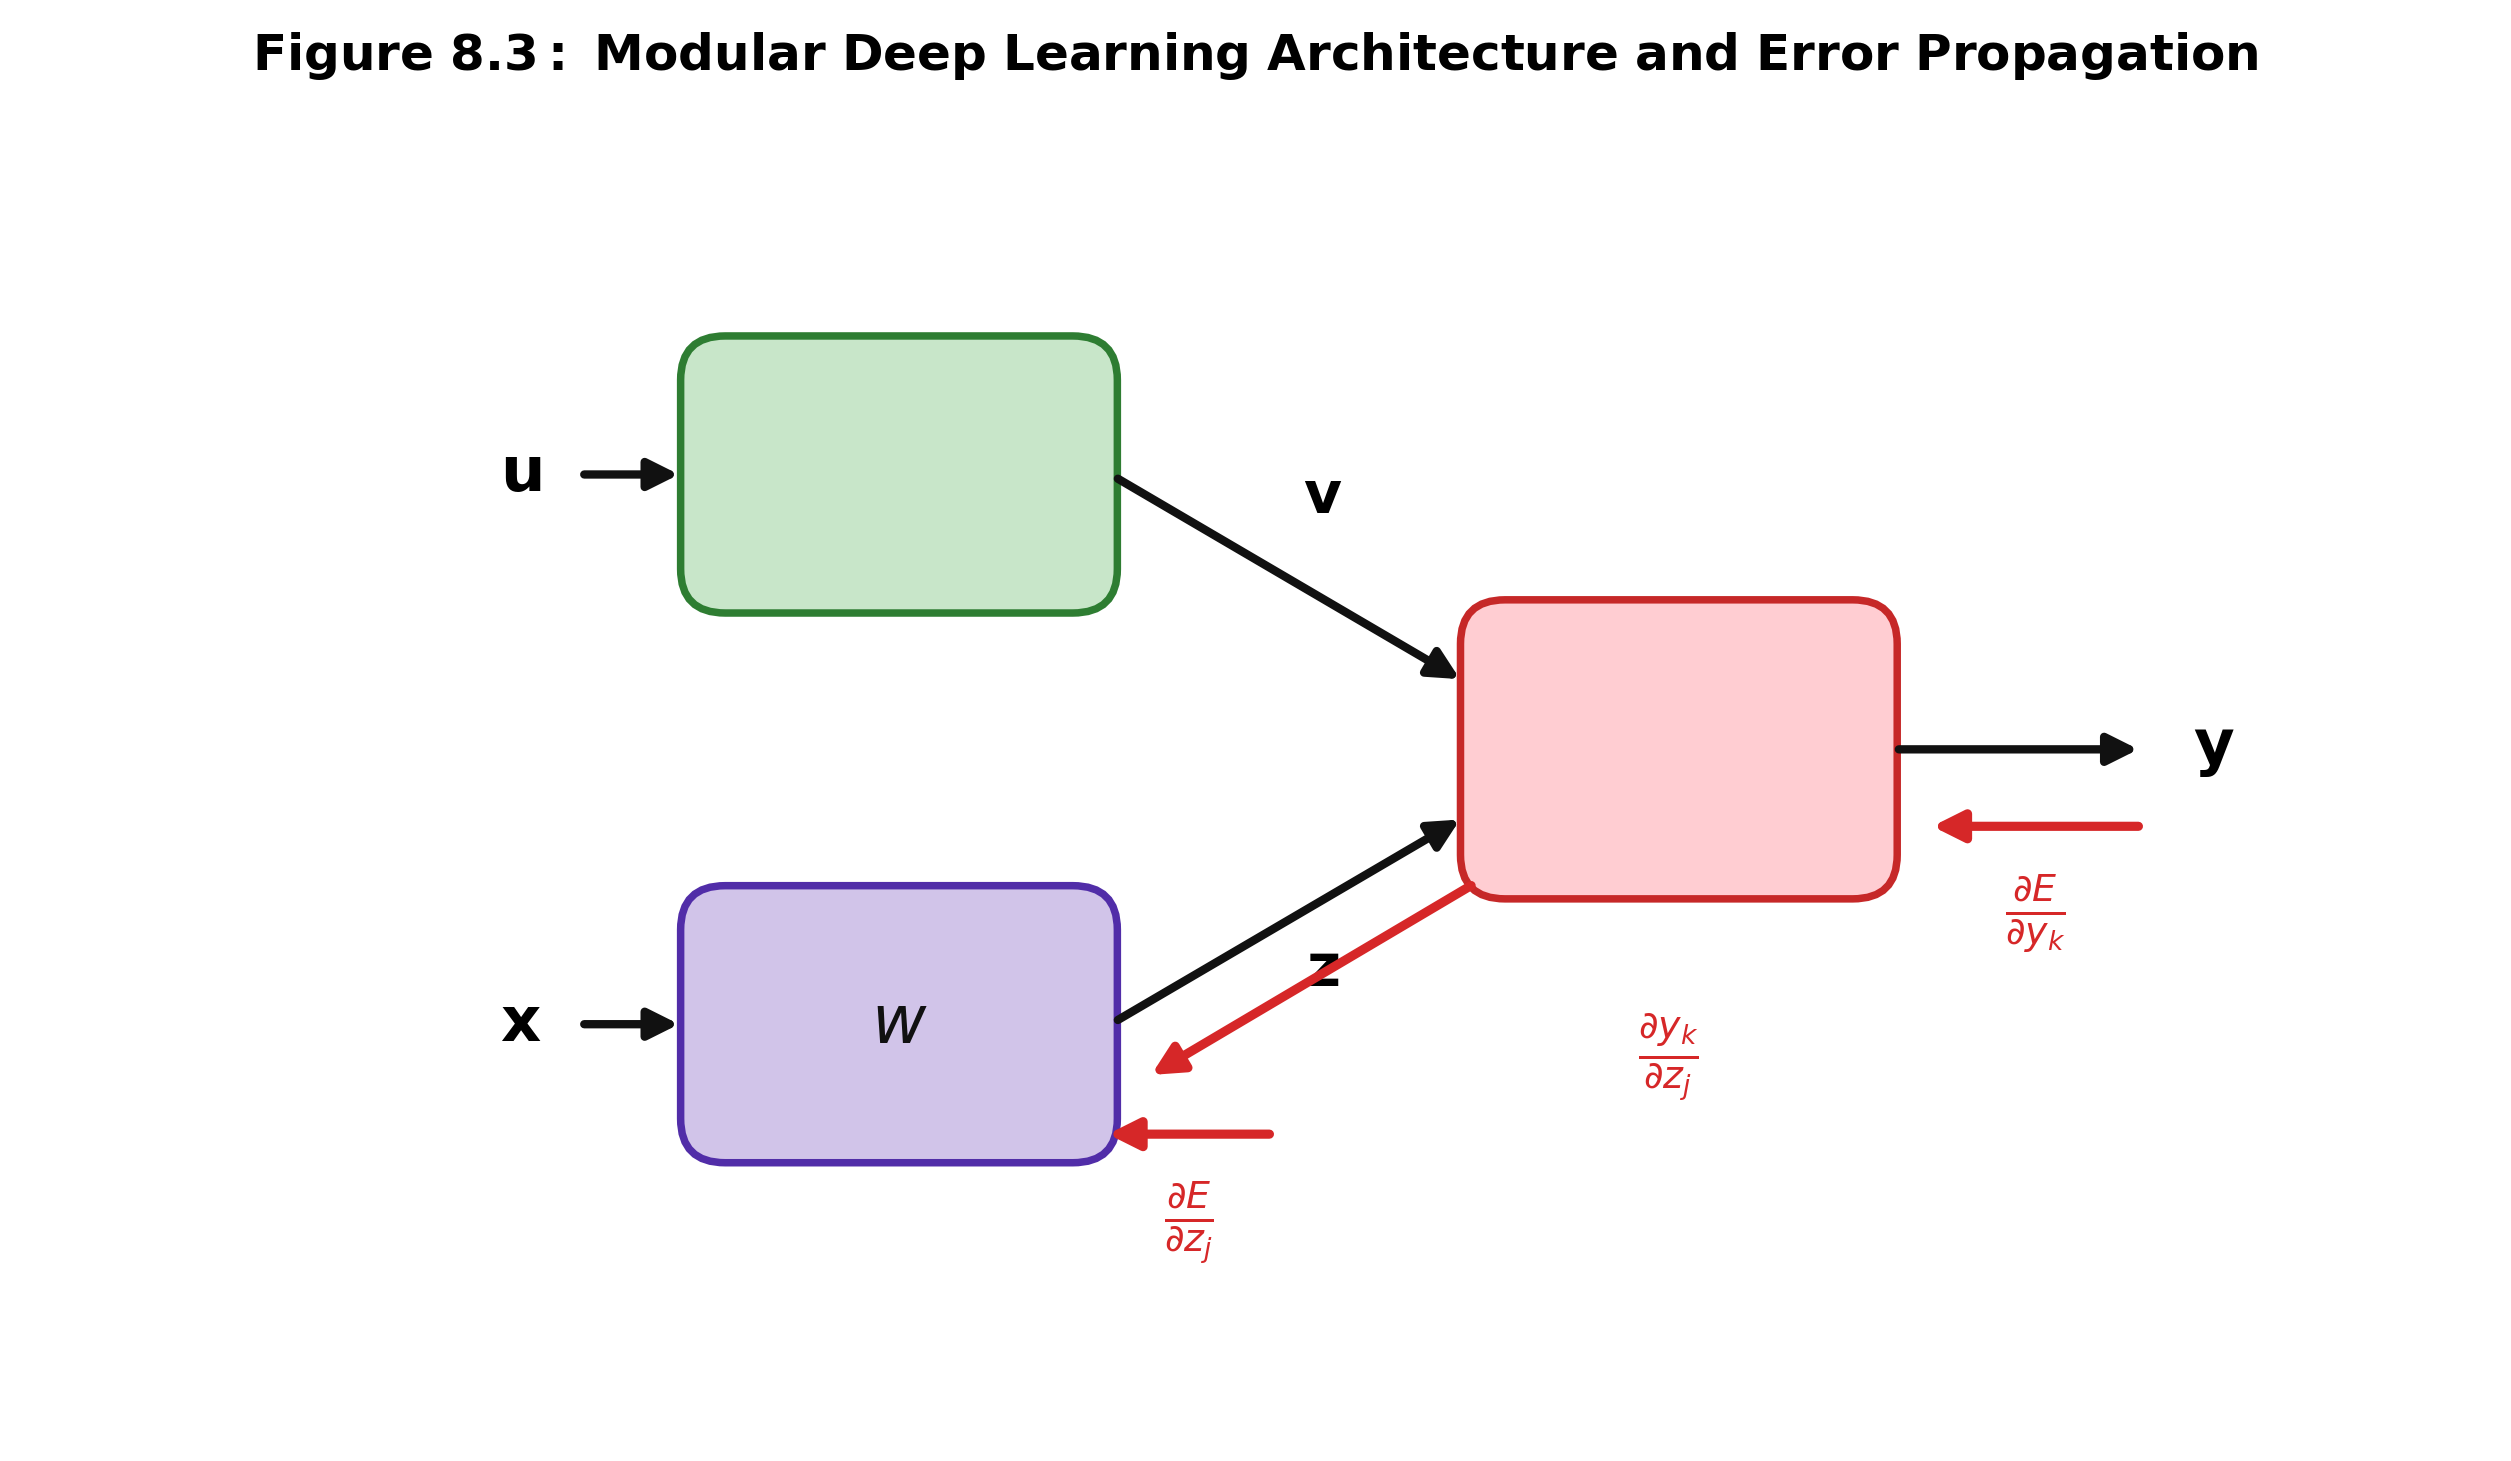

In [6]:
# Figure 8.3の生成と表示（モジュール化アーキテクチャ）
fig_8_3 = generate_figure_8_3(save_both=True)
plt.show()


In [7]:
# ヤコビ行列の計算と感度解析シミュレーション
x_point = np.array([0.4, -0.6, 0.2])

# 解析的ヤコビ行列の計算
J_ana = compute_jacobian_analytical(mlp, x_point)
# 数値差分によるヤコビ行列の計算
J_num = compute_jacobian_numerical(mlp, x_point, epsilon=1e-6)

print(f"入力 x: {x_point}")
print(f"解析的ヤコビ行列 J (shape {J_ana.shape}):\n", np.round(J_ana, 4))
print(f"数値差分ヤコビ行列との最大誤差: {np.max(np.abs(J_ana - J_num)):.2e}")

# 感度解析 Delta y approx J Delta x の検証
delta_x = np.array([1e-4, -2e-4, 1.5e-4])
y_base = mlp.predict(x_point).ravel()
y_perturbed = mlp.predict(x_point + delta_x).ravel()
delta_y_actual = y_perturbed - y_base
delta_y_predicted = J_ana @ delta_x

print(f"摂動 Delta x: {delta_x}")
print(f"実際の出力変化 Delta y:    {delta_y_actual}")
print(f"ヤコビ予測出力変化 J Delta x: {delta_y_predicted}")
rel_sens_err = np.linalg.norm(delta_y_actual - delta_y_predicted) / np.linalg.norm(delta_y_actual)
print(f"感度予測の相対誤差: {rel_sens_err:.2e}")
assert rel_sens_err < 1e-3


入力 x: [ 0.4 -0.6  0.2]
解析的ヤコビ行列 J (shape (2, 3)):
 [[ 0.4302 -0.7015 -0.4609]
 [-0.106   0.181   0.3018]]
数値差分ヤコビ行列との最大誤差: 2.99e-11
摂動 Delta x: [ 0.0001  -0.0002   0.00015]
実際の出力変化 Delta y:    [ 1.14170321e-04 -1.51540703e-06]
ヤコビ予測出力変化 J Delta x: [ 1.14177752e-04 -1.51765328e-06]
感度予測の相対誤差: 6.80e-05


## 8.1.6 ヘッセ行列 (The Hessian matrix)

### 定義と計算コスト
ネットワークのパラメータベクトルを $\mathbf{w} \in \mathbb{R}^W$ とするとき、誤差関数の2階偏導関数からなる対称行列を**ヘッセ行列（Hessian matrix）**と呼びます：
$$
H_{ij} \equiv \frac{\partial^2 E}{\partial w_i \partial w_j} \tag{8.37}
$$
ヘッセ行列は以下の分野で中心的な役割を果たします：
1. **2次最適化法**: ニュートン・ラフソン法やレーベンバーグ・マルカート法などによる高次曲率の利用。
2. **ベイズ深層学習**: ラプラス近似による事後分布のガウス近似とエビデンス評価。
3. **モデル圧縮・量子化**: パラメータ微小変化に対する損失感度の評価（最適脳損傷・最適脳外科手術手法、LLMの重み量子化）。

しかし、$W$ 個のパラメータに対してヘッセ行列のサイズは $W \times W$ であり、厳密評価には $O(W^2)$ の計算コスト、逆行列の計算には $O(W^3)$ を要します。パラメータ数が数億〜数千億に及ぶ現代の深層学習では、完全なヘッセ行列の保持すら困難であるため、効果的な近似法が必須となります。

---

### 主要なヘッセ近似と計算法
1. **ヘッセ・ベクトル積 (Hessian-Vector Product: $v^T H$ / $Hv$)**:
   ヘッセ行列そのものを陽に計算・保持せず、任意のベクトル $\mathbf{v}$ との積 $\mathbf{H}\mathbf{v}$ のみを必要とする場合、Pearlmutter (1994) や Møller (1993) の手法により **$O(W)$ ステップ**で高速に計算可能です：
   $$
   \mathbf{H} \mathbf{v} \approx \frac{\nabla E(\mathbf{w} + \epsilon \mathbf{v}) - \nabla E(\mathbf{w} - \epsilon \mathbf{v})}{2\epsilon}
   $$
2. **対角近似 (Diagonal Approximation)**:
   非対角成分をゼロと仮定し、対角成分 $\frac{\partial^2 E}{\partial w_i^2}$ のみ保持する手法。メモリは $O(W)$ で逆行列も $O(W)$ ですが、一般に強い相関（非対角成分）が存在するため慎重な扱いを要します。
3. **外積近似（ガウス・ニュートン近似 / レーベンバーグ・マルカート近似）**:
   二乗和誤差 $E = \frac{1}{2} \sum_{n=1}^N (y_n - t_n)^2$ に対し、2階微分を正確に展開すると（Exercise 8.8）：
   $$
   \mathbf{H} = \nabla \nabla E = \sum_{n=1}^N \nabla y_n (\nabla y_n)^T + \sum_{n=1}^N (y_n - t_n) \nabla \nabla y_n \tag{8.39}
   $$
   ネットワークが適切に訓練されていれば、出力 $y_n$ は目標値 $t_n$ に十分近いため、第2項 $(y_n - t_n) \nabla \nabla y_n$ は無視できます。
   さらに、4.2節で示した通り二乗損失を最小化する最適予測関数は条件付き平均 $\mathbb{E}[t|\mathbf{x}]$ であるため、$(y_n - t_n)$ は平均ゼロの確率変数です。この誤差が2階微分項と無相関であると仮定すると、データ点全体の総和において第2項はゼロへと平均化されます（Exercise 8.9）。
   
   したがって、第2項を省略することで**外積近似（Outer product approximation）**が得られます：
   $$
   \mathbf{H} \approx \sum_{n=1}^N \nabla a_n \nabla a_n^T \tag{8.40}
   $$
   外積近似の利点：
   - 1階勾配 $\nabla a_n$ のみを用いて構成できるため、通常の逆伝播法により $O(W)$ で各項を評価可能。
   - **必ず半正定値（Positive semi-definite）**となり、固有値が負になる不安定性が原理的に生じない。

ロジスティック・シグモイド出力とクロスエントロピー誤差に対しては、対応する近似式は次式となります（Exercise 8.10）：
$$
\mathbf{H} \approx \sum_{n=1}^N y_n (1 - y_n) \nabla a_n \nabla a_n^T \tag{8.41}
$$

In [8]:
# ヘッセ行列の厳密評価、外積近似、ヘッセ・ベクトル積の数値検証
H_exact = compute_exact_hessian_numerical(mlp, X_sample, T_sample, epsilon=1e-5)
H_outer = compute_hessian_outer_product(mlp, X_sample)

print(f"パラメータ次元 W = {mlp.num_parameters}")
print(f"厳密ヘッセ行列 H_exact の形状: {H_exact.shape}")
print(f"ヘッセ行列の対称性 ||H - H^T||: {np.linalg.norm(H_exact - H_exact.T):.2e}")

# 固有値解析（半正定値性の確認）
eig_exact = np.linalg.eigvalsh(H_exact)
eig_outer = np.linalg.eigvalsh(H_outer)

print(f"厳密ヘッセ行列の最小固有値: {np.min(eig_exact):.4f}")
print(f"外積近似ヘッセ行列の最小固有値: {np.min(eig_outer):.4e} (>= 0 保証)")

# ヘッセ・ベクトル積の検証
v_rand = np.random.randn(mlp.num_parameters)
v_rand /= np.linalg.norm(v_rand)

Hv_from_matrix = H_exact @ v_rand
Hv_direct_O_W = hessian_vector_product_fd(mlp, X_sample, T_sample, v_rand, epsilon=1e-5)

rel_diff_Hv = np.linalg.norm(Hv_from_matrix - Hv_direct_O_W) / np.linalg.norm(Hv_from_matrix)
print(f"行列積 Hv と O(W)高速差分積の相対差: {rel_diff_Hv:.2e} (< 1e-4)")
assert rel_diff_Hv < 1e-4


パラメータ次元 W = 26
厳密ヘッセ行列 H_exact の形状: (26, 26)
ヘッセ行列の対称性 ||H - H^T||: 0.00e+00
厳密ヘッセ行列の最小固有値: -1.9262
外積近似ヘッセ行列の最小固有値: -6.6858e-16 (>= 0 保証)
行列積 Hv と O(W)高速差分積の相対差: 1.70e-11 (< 1e-4)


## 8.1節のまとめ

本節では、深層学習における中核技術である「勾配の評価」を数理・アルゴリズム・計算量の観点から体系的に探求しました：
1. **誤差逆伝播法 (Backpropagation)**:
   - 連鎖律に基づき、出力層の誤差信号 $\delta_k = y_k - t_k$ を隠れ層へ逆伝播 $\delta_j = h'(a_j) \sum_k w_{kj} \delta_k$ させることで、全パラメータの勾配をわずか **$O(W)$** で評価できる。
2. **数値微分 (Numerical Differentiation)**:
   - 前進差分 $O(\epsilon)$ と中心差分 $O(\epsilon^2)$ の違いをテイラー展開で証明。
   - 計算コストが $O(W^2)$ に悪化するため学習には使えないが、逆伝播コードの数学的正当性を検証するデバッグ手段として不可欠。
   - ステップ幅 $\epsilon$ に対する打ち切り誤差と丸め誤差のトレードオフ（Figure 8.2）。
3. **ヤコビ行列 (The Jacobian Matrix)**:
   - 出力の入力に対する局所感度 $\Delta \mathbf{y} \approx \mathbf{J} \Delta \mathbf{x}$ を表し、モジュール化深層学習における結合ブロックとして機能（Figure 8.3）。
   - 逆伝播漸化式により効率的に評価可能。
4. **ヘッセ行列 (The Hessian Matrix)**:
   - 2階曲率情報を与えるが、サイズ $W \times W$ のため計算・保持が重い。
   - 半正定値を保証する外積近似（ガウス・ニュートン近似）や、明示的な行列生成を回避する $O(W)$ ヘッセ・ベクトル積の有用性を確認。

次節（8.2節）では、手作業による逆伝播式の導出を不要にし、任意のコンピュータプログラムから機械精度で導関数を自動生成する**自動微分 (Automatic Differentiation)**の枠組みへと進みます。